In [ ]:
!pip install stable-baselines3[extra]
!pip install gymnasium[mujoco]

In [ ]:
import os
import random
import time

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from stable_baselines3.common.buffers import ReplayBuffer

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# settings
env_id = "HalfCheetah-v5"

# total number of timesteps for training over multiple episodes
# total_timesteps = 1_000_000
total_timesteps = 50_000

# adam learning rate
learning_rate = 3e-4

# number of transitions to store in replay buffer
buffer_size = 1_000_000

# discount factor
gamma = 0.99

# target network update constant
# θ_target = 𝜏 * θ + (1 - 𝜏) * θ_target
tau = 0.005

# number of timesteps between target network updates
policy_update_period = 2

# size of sample from replay buffer
batch_size = 256

# number of steps before beginning training
num_steps_before_training = 25_000

# optional: set seed for reproducibility
# seed = 123
seed = None

# standard deviation of exploration noise
exploration_sd = 0.1

# standard deviation for noise added to policy target
policy_target_sd = 0.2

# max magnitude of policy target noise
policy_target_noise_max = 0.5

In [ ]:
# will encapsulate in lambda later
def make_env(env_id, capture_video, seed=None):
  if capture_video:
    env = gym.make(env_id, render_mode="rgb_array")
    env = gym.wrappers.RecordVideo(env, "td3_videos", episode_trigger=lambda episode: True)
  else:
    env = gym.make(env_id)
  env = gym.wrappers.RecordEpisodeStatistics(env)

  obs_space = env.observation_space
  env = gym.wrappers.TransformObservation(
    env,
    lambda obs: obs.astype(np.float32),
    observation_space=gym.spaces.Box(
        low=obs_space.low,
        high=obs_space.high,
        shape=obs_space.shape,
        dtype=np.float32,
    ),
  )

  # To get reproducible sampling of actions, a seed can be set with env.action_space.seed(123)
  if seed is not None:
    env.action_space.seed(seed)
  return env


In [ ]:
class QNetwork(nn.Module):
  def __init__(self, env):
    super().__init__()
    n_inputs = np.prod(env.single_observation_space.shape) + \
      np.prod(env.single_action_space.shape)
    self.fc1 = nn.Linear(n_inputs, 256)
    self.fc2 = nn.Linear(256, 256)
    self.fc3 = nn.Linear(256, 1)

  def forward(self, x, a):
    x = torch.cat([x, a], 1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [ ]:
class Actor(nn.Module):
  def __init__(self, env):
    super().__init__()
    self.fc1 = nn.Linear(np.array(env.single_observation_space.shape).prod(), 256)
    self.fc2 = nn.Linear(256, 256)
    self.fc_mu = nn.Linear(256, np.prod(env.single_action_space.shape))

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    return torch.tanh(self.fc_mu(x))

In [ ]:
# optional: set seeds for reproducibility
if seed is not None:
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.backends.cudnn.deterministic = True

In [ ]:
envs = gym.vector.SyncVectorEnv(
  [lambda: make_env(env_id, False, seed)],
  autoreset_mode=gym.vector.AutoresetMode.SAME_STEP
)

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [ ]:
device = torch.device(
  "cuda" if torch.cuda.is_available() else
  # "mps" if torch.backends.mps.is_available() else # cpu is faster on mac
  "cpu"
)

In [ ]:
# make actor networks
actor = Actor(envs).to(device)
actor_target = Actor(envs).to(device)
actor_target.load_state_dict(actor.state_dict())

<All keys matched successfully>

In [ ]:
# make q networks
q1 = QNetwork(envs).to(device)
q1_target = QNetwork(envs).to(device)
q1_target.load_state_dict(q1.state_dict())
q2 = QNetwork(envs).to(device)
q2_target = QNetwork(envs).to(device)
q2_target.load_state_dict(q2.state_dict())

<All keys matched successfully>

In [ ]:
# make optimizers
actor_optimizer = optim.Adam(actor.parameters(), lr=learning_rate)
q_optimizer = optim.Adam(
    list(q1.parameters()) + list(q2.parameters()), lr=learning_rate)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
envs.single_observation_space.dtype = np.float32

In [ ]:
rb = ReplayBuffer(
  buffer_size,
  envs.single_observation_space,
  envs.single_action_space,
  device,
  handle_timeout_termination=False,
)

In [ ]:
# training loop
start_time = time.time()
episode_returns = []
obs, _ = envs.reset(seed=seed)
for global_step in range(total_timesteps):

  # select action
  if global_step < num_steps_before_training:
    actions = np.array([envs.single_action_space.sample() \
                        for _ in range(envs.num_envs)])
  else:
    with torch.no_grad():
      actions = actor(torch.Tensor(obs).to(device))
      actions += torch.randn_like(actions) * exploration_sd
      actions = actions.cpu().numpy()

  # clip actions b/c we added noise
  actions = actions.clip(
      envs.single_action_space.low, envs.single_action_space.high)

  # take a step in the environment
  next_obs, rewards, terminateds, truncateds, infos = envs.step(actions)

  # store and print episode return
  if "final_info" in infos:
    ret = infos['final_info']['episode']['r'][0]
    print(f"global_step={global_step}, episodic_return={ret}")
    episode_returns.append(ret)

  # since we use same step
  real_next_obs = next_obs.copy()
  for i, truncated in enumerate(truncateds):
      if truncated:
          real_next_obs[i] = infos["final_obs"][i]
  rb.add(obs, real_next_obs, actions, rewards, terminateds, infos)

  # don't forget!
  obs = next_obs

  # training!
  if global_step > num_steps_before_training:
    data = rb.sample(batch_size)

    # we'll train the q network on every step
    with torch.no_grad():
      action_noise = torch.randn_like(data.actions, device=device) * \
        policy_target_sd
      action_noise = action_noise.clamp(
          -policy_target_noise_max, policy_target_noise_max)
      a2 = actor_target(data.next_observations) + action_noise
      a2 = a2.clamp(
          envs.single_action_space.low[0], envs.single_action_space.high[0])

      q1_targ = q1_target(data.next_observations, a2)
      q2_targ = q2_target(data.next_observations, a2)
      q_targ = torch.min(q1_targ, q2_targ)
      td_target = data.rewards.flatten() + (1 - data.dones.flatten()) \
        * gamma * q_targ.view(-1)

    q1_pred = q1(data.observations, data.actions).view(-1)
    q2_pred = q2(data.observations, data.actions).view(-1)
    q1_loss = F.mse_loss(q1_pred, td_target)
    q2_loss = F.mse_loss(q2_pred, td_target)
    q_loss = q1_loss + q2_loss

    # gradient descent step
    q_optimizer.zero_grad()
    q_loss.backward()
    q_optimizer.step()

    # we'll train the actor every `policy_update_period` steps
    if global_step % policy_update_period == 0:
      actor_loss = -q1(data.observations, actor(data.observations)).mean()
      actor_optimizer.zero_grad()
      actor_loss.backward()
      actor_optimizer.step()

      # update target networks
      for param, target_param in zip(
          q1.parameters(), q1_target.parameters()):
        target_param.data.copy_(
            tau * param.data + (1 - tau) * target_param.data)
      for param, target_param in zip(
          q2.parameters(), q2_target.parameters()):
        target_param.data.copy_(
            tau * param.data + (1 - tau) * target_param.data)
      for param, target_param in zip(
          actor.parameters(), actor_target.parameters()):
        target_param.data.copy_(
            tau * param.data + (1 - tau) * target_param.data)

    if global_step % 100 == 0:
      print("steps per second:", int(global_step / (time.time() - start_time)))

envs.close()


global_step=999, episodic_return=-250.91079069373967
global_step=1999, episodic_return=-194.2412009819415
global_step=2999, episodic_return=-370.378147604961
global_step=3999, episodic_return=-484.1635893725916
global_step=4999, episodic_return=-311.85678166349044
global_step=5999, episodic_return=-291.18114537593914
global_step=6999, episodic_return=-468.43612764933664
global_step=7999, episodic_return=-185.33741850204436
global_step=8999, episodic_return=-377.70474268503733
global_step=9999, episodic_return=-290.69419780186087
global_step=10999, episodic_return=-320.60372385038914
global_step=11999, episodic_return=-292.9292561535593
global_step=12999, episodic_return=-273.0945174544738
global_step=13999, episodic_return=-475.48094972624546
global_step=14999, episodic_return=-223.51584123568827
global_step=15999, episodic_return=-278.46993767252997
global_step=16999, episodic_return=-276.6516773998432
global_step=17999, episodic_return=-219.8740293061761
global_step=18999, episodic_r

In [ ]:
def smooth(x, a=0.1):
  y = [x[0]]
  for xi in x[1:]:
    yi = a * xi + (1 - a) * y[-1]
    y.append(yi)
  return y

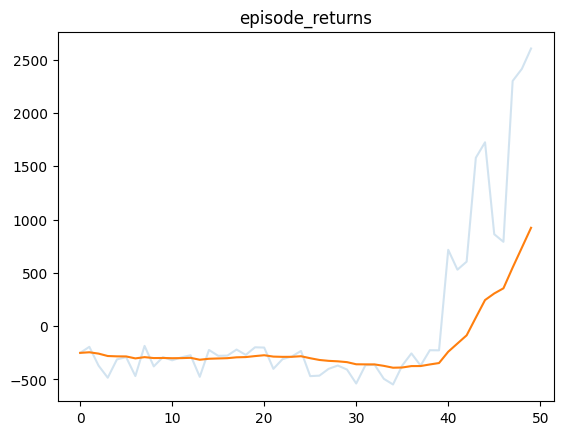

In [ ]:
plt.plot(episode_returns, alpha=0.2)
plt.plot(smooth(episode_returns))
plt.title("episode_returns");
plt.show();

In [ ]:
# save models
model_path = "td3_actor.pth"
torch.save(actor.state_dict(), model_path)

In [ ]:
# load model for eval
envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(env_id, True)],
        autoreset_mode=gym.vector.AutoresetMode.SAME_STEP)
model = Actor(envs_eval).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/td3_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Actor(
  (fc1): Linear(in_features=17, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=6, bias=True)
)

In [ ]:
# colab only

import os

# Set MuJoCo to use EGL for headless rendering
os.environ['MUJOCO_GL'] = 'egl'

# Optional: Set PyOpenGL to use EGL as well
os.environ['PYOPENGL_PLATFORM'] = 'egl'

In [ ]:
!apt-get update -y
!apt-get install -y libosmesa6-dev libgl1-mesa-glx libglfw3 libglew-dev

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
# evaluate the model
n_episodes_eval = 10
eval_returns = np.zeros(n_episodes_eval)
obs, _ = envs_eval.reset()
for i in range(n_episodes_eval):
  episode_done = False
  while not episode_done:
    with torch.no_grad():
      actions = model(torch.Tensor(obs).to(device))
      actions = actions.cpu().numpy()
    obs, rewards, terminateds, truncateds, infos = envs_eval.step(actions)

    if terminateds[0] or truncateds[0]:
      if 'final_info' in infos:
        if 'episode' in infos['final_info']:
          episode_done = True
          ret = infos['final_info']["episode"]["r"][0]
          print(f"episode={i}, return={ret}")
          eval_returns[i] = ret

envs_eval.close()

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


episode=0, return=3003.805394971534
episode=1, return=2944.9292466069564
episode=2, return=2601.8549269855353
episode=3, return=2984.1793869803837
episode=4, return=2867.5837282728094
episode=5, return=2973.053313106655
episode=6, return=2834.9847013140884
episode=7, return=2873.9412826852413
episode=8, return=2959.5240380335267
episode=9, return=2756.3912513454134


Text(0, 0.5, 'Frequency')

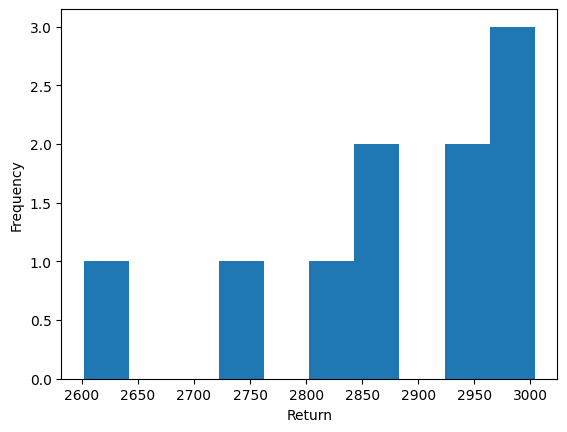

In [ ]:
# plot eval return distribution
plt.hist(eval_returns)
plt.xlabel("Return")
plt.ylabel("Frequency")

In [ ]:
from IPython.display import Video, display

display(Video("/content/td3_videos/rl-video-episode-0.mp4", embed=True))

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=ajMgus4HVOdGR3CZkAAu7w&n=TD3+MuJoCo)